# Transformer Model
In this notebook, we show an example of how Transformer can be used with darts.
If you are new to darts, we recommend you first follow the [quick start](https://unit8co.github.io/darts/quickstart/00-quickstart.html) notebook.

In [1]:
# fix python path if working locally
from utils import fix_pythonpath_if_working_locally

fix_pythonpath_if_working_locally()

In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [3]:
# use darts plotting style
from darts import set_option

set_option("plotting.use_darts_style", True)

In [4]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from darts.dataprocessing.transformers import Scaler
from darts.datasets import AirPassengersDataset, SunspotsDataset
from darts.metrics import mape
from darts.models import ExponentialSmoothing, TransformerModel
from darts.utils.statistics import check_seasonality

warnings.filterwarnings("ignore")
import logging

logging.disable(logging.CRITICAL)

## Air Passengers Example

First, we will test the performance of the transformer architecture on the 'air passengers' dataset.

In [ ]:
# Read data:
series = AirPassengersDataset().load().astype(np.float32)

# Create training and validation sets:
train, val = series.split_after(pd.Timestamp("19590101"))

# Normalize the time series (note: we avoid fitting the transformer on the validation set)
# Change name
scaler = Scaler()
train_scaled = scaler.fit_transform(train)
val_scaled = scaler.transform(val)
series_scaled = scaler.transform(series)

In [ ]:
f"the 'air passengers' dataset has {len(series)} data points"

"the 'air passengers' dataset has 144 data points"

We train a standard transformer architecture with default hyperparameters, tweaking only two of them:

* _d\_model_, the input dimensionality of the transformer architecture (*after* performing time series embedding). Its default value is 512. We lower the value from 512 to 64, since it is hard to learn such an high-dimensional representation from an univariate time series
* _nhead_, the number of heads in the multi-head attention mechanism. We increase the value from 8 to 32. This means that we compute multi-head attention with 32 heads of size _d\_model_/_nhead_=64/32=2 each. This way, we obtain low-dimensional heads that are hopefully suitable to learn from univariate time series

The goal is to perform one-step forecasting.

In [ ]:
my_model = TransformerModel(
    input_chunk_length=12,
    output_chunk_length=1,
    batch_size=32,
    n_epochs=200,
    model_name="air_transformer",
    nr_epochs_val_period=10,
    d_model=16,
    nhead=8,
    num_encoder_layers=2,
    num_decoder_layers=2,
    dim_feedforward=128,
    dropout=0.1,
    activation="relu",
    random_state=42,
    save_checkpoints=True,
    force_reset=True,
)

In [ ]:
my_model.fit(series=train_scaled, val_series=val_scaled, verbose=True)

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

TransformerModel(output_chunk_shift=0, d_model=16, nhead=8, num_encoder_layers=2, num_decoder_layers=2, dim_feedforward=128, dropout=0.1, activation=relu, norm_type=None, custom_encoder=None, custom_decoder=None, input_chunk_length=12, output_chunk_length=1, batch_size=32, n_epochs=200, model_name=air_transformer, nr_epochs_val_period=10, random_state=42, save_checkpoints=True, force_reset=True)

Let's look at the predictions on the validation set.

First, by using the "current" model - i.e., the model at the end of the training procedure:

Predicting: |          | 0/? [00:00<?, ?it/s]

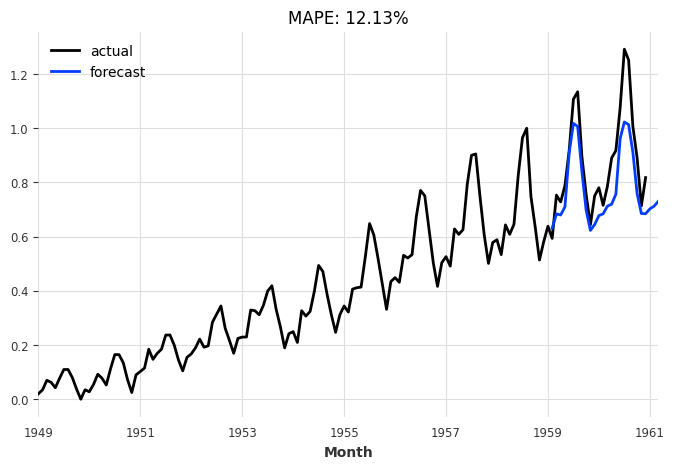

In [ ]:
# this function evaluates a model on a given validation set for n time-steps
def eval_model(model, n, series, val_series):
    pred_series = model.predict(n=n)
    plt.figure(figsize=(8, 5))
    series.plot(label="actual")
    pred_series.plot(label="forecast")
    plt.title(f"MAPE: {mape(pred_series, val_series):.2f}%")
    plt.legend()


eval_model(my_model, 26, series_scaled, val_scaled)

Then, by using the best model obtained over training, according to validation loss:

Predicting: |          | 0/? [00:00<?, ?it/s]

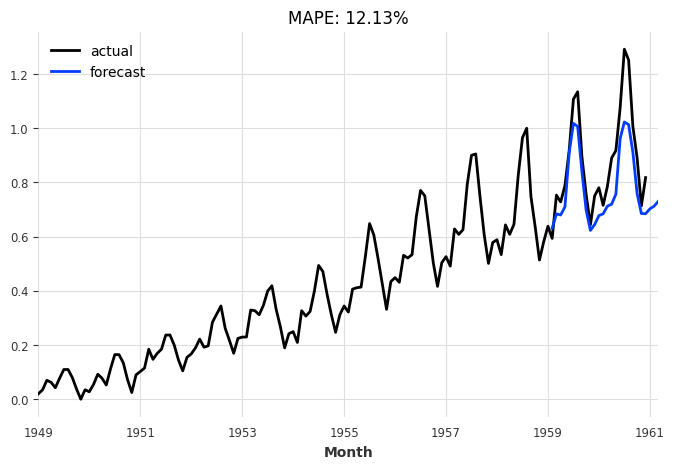

In [ ]:
best_model = TransformerModel.load_from_checkpoint(
    model_name="air_transformer", best=True
)
eval_model(best_model, 26, series_scaled, val_scaled)

Let's backtest our `Transformer` model to evaluates its performance at a forecast horizon of 6 months:

In [ ]:
backtest_series = my_model.historical_forecasts(
    series=series_scaled,
    start=pd.Timestamp("19590101"),
    forecast_horizon=6,
    retrain=False,
    verbose=True,
)

Predicting: |          | 0/? [00:00<?, ?it/s]

MAPE: 7.62%


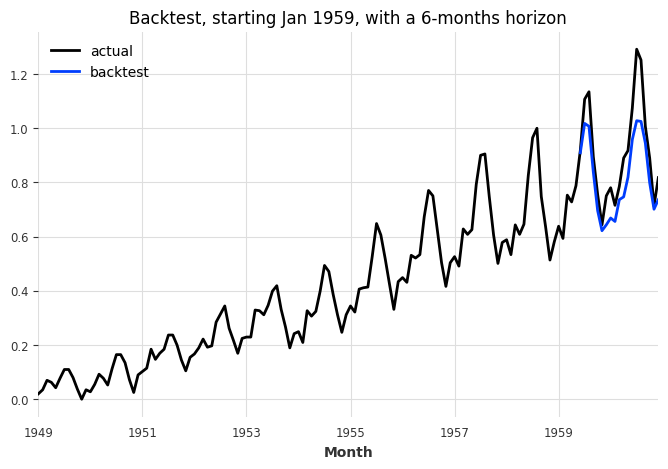

In [ ]:
plt.figure(figsize=(8, 5))
series_scaled.plot(label="actual", lw=2)
backtest_series.plot(label="backtest", lw=2)
plt.legend()
plt.title("Backtest, starting Jan 1959, with a 6-months horizon")
print(
    "MAPE: {:.2f}%".format(
        mape(
            scaler.inverse_transform(series_scaled),
            scaler.inverse_transform(backtest_series),
        )
    )
)

### Monthly Sun spots Example

Now, let's test the transformer architecture on a more complex dataset, the 'monthly sunspots'. 

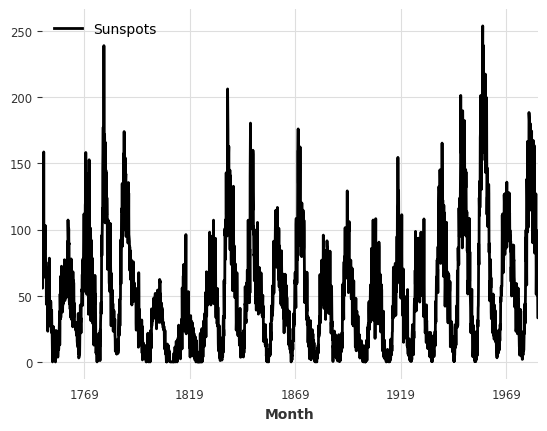

In [ ]:
series_sunspot = SunspotsDataset().load().astype(np.float32)

series_sunspot.plot()
check_seasonality(series_sunspot, max_lag=240)

train_sp, val_sp = series_sunspot.split_after(pd.Timestamp("19401001"))

scaler_sunspot = Scaler()
train_sp_scaled = scaler_sunspot.fit_transform(train_sp)
val_sp_scaled = scaler_sunspot.transform(val_sp)
series_sp_scaled = scaler_sunspot.transform(series_sunspot)

In [ ]:
f"the 'monthly sun spots' dataset has {len(series_sunspot)} data points"

"the 'monthly sun spots' dataset has 2820 data points"

First, let's perform one-step ahead forecasting.

In [ ]:
my_model_sp = TransformerModel(
    batch_size=32,
    input_chunk_length=125,
    output_chunk_length=36,
    n_epochs=20,
    model_name="sun_spots_transformer",
    nr_epochs_val_period=5,
    d_model=16,
    nhead=4,
    num_encoder_layers=2,
    num_decoder_layers=2,
    dim_feedforward=128,
    dropout=0.1,
    random_state=42,
    optimizer_kwargs={"lr": 1e-3},
    save_checkpoints=True,
    force_reset=True,
)

In [ ]:
my_model_sp.fit(series=train_sp_scaled, val_series=val_sp_scaled, verbose=True)

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

historical forecasts:   0%|          | 0/49 [00:00<?, ?it/s]

Transformer MAPE: 38.167416
ETS MAPE: 1565.2371034680634


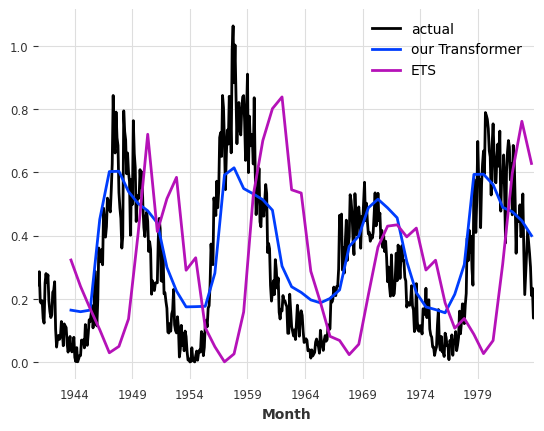

In [ ]:
# this function is used to backtest the model at a forecasting horizon of three years (36 months)
def backtest(testing_model):
    # Compute the backtest predictions with the two models
    pred_series = testing_model.historical_forecasts(
        series=series_sp_scaled,
        start=pd.Timestamp("19401001"),
        forecast_horizon=36,
        stride=10,
        retrain=False,
        verbose=True,
    )

    pred_series_ets = ExponentialSmoothing().historical_forecasts(
        series=series_sp_scaled,
        start=pd.Timestamp("19401001"),
        forecast_horizon=36,
        stride=10,
        retrain=True,
        verbose=True,
    )
    val_sp_scaled.plot(label="actual")
    pred_series.plot(label="our Transformer")
    pred_series_ets.plot(label="ETS")
    plt.legend()
    print("Transformer MAPE:", mape(pred_series, val_sp_scaled))
    print("ETS MAPE:", mape(pred_series_ets, val_sp_scaled))


best_model_sp = TransformerModel.load_from_checkpoint(
    model_name="sun_spots_transformer", best=True
)
backtest(best_model_sp)